# Sliding Mode Control (SMC): idea central

El **Sliding Mode Control** es una estrategia de control robusto basada en forzar
la dinámica del sistema a evolucionar sobre una **variedad de menor dimensión**
(superficie deslizante), donde la dinámica queda completamente determinada
por el diseño del controlador.

La robustez surge del hecho de que:
- la **alcanzabilidad** de la superficie es garantizada aun con incertidumbres,
- la **dinámica en la superficie** es impuesta por el diseñador.




In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Sistema de estudio: masa–resorte

Consideremos el sistema clásico masa–resorte:

$$
m \ddot x + k x = u
$$

Definiendo el estado:

$$
x_1 = x, \quad x_2 = \dot x
$$

la dinámica en espacio de estados queda:

$$
\begin{cases}
\dot x_1 = x_2 \\
\dot x_2 = -\frac{k}{m} x_1 + \frac{1}{m} u
\end{cases}
$$

Este sistema es de **segundo orden** y su comportamiento libre es oscilatorio.




In [ ]:
# Sistema masa resorte: bien básico
m = 1.0
k = 1.0
b = 0           # Es más visual cuando no hay pérdidas

## Motivación del SMC

En lugar de controlar directamente ambos estados, SMC propone:

1. Definir una **superficie deslizante** \( s(x) = 0 \)
2. Forzar al sistema a alcanzar dicha superficie
3. Una vez allí, hacer que **permanezca sobre ella**

La superficie se elige de modo tal que, sobre ella, la dinámica tenga
el comportamiento deseado.

---

## Superficie deslizante

Elegimos una superficie lineal:

$$
s(x) = x_2 + \lambda x_1
$$

Esta ecuación define una **recta en el plano de estados** \((x_1, x_2)\).

Interpretación:
- la superficie impone la relación \( \dot x = -\lambda x \)
- es decir, un **sistema de primer orden estable**
- el polo de la dinámica reducida es \( -\lambda \)

👉 La performance deseada queda completamente determinada por la elección de \( \lambda \).




In [ ]:
# Condiciones de diseño
lambda_s = 1.0  # fijamos la dinámica deseada
K = 2.0         # Amplitud de la acción de control para llevar a la superficie deslizante


## Dinámica en la superficie (sliding)

Si el sistema logra permanecer en la superficie \( s = 0 \):

\[
x_2 = -\lambda x_1
\quad \Rightarrow \quad
\dot x_1 = -\lambda x_1
\]

Esto implica:
- convergencia exponencial al origen
- reducción del orden del sistema
- dinámica **independiente de \( m \) y \( k \)**


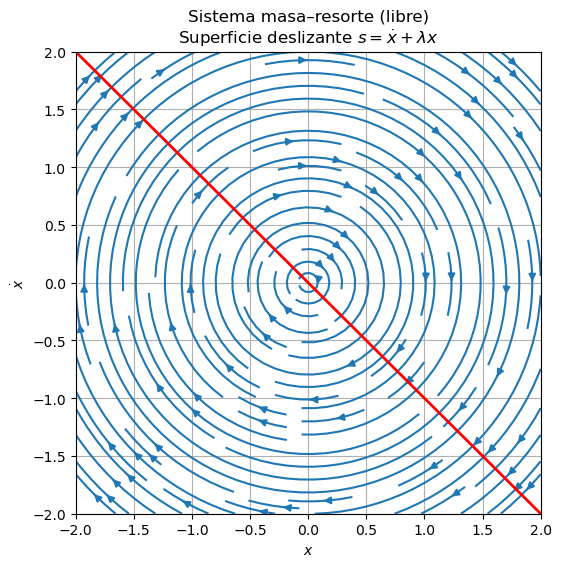

In [3]:
# Campo vectorial del sistema libre
x1 = np.linspace(-2, 2, 25)
x2 = np.linspace(-2, 2, 25)
X1, X2 = np.meshgrid(x1, x2)

X1_dot = X2
X2_dot = -(k/m) * X1 - (b/m) * X2

# Superficie deslizante
s = X2 + lambda_s * X1


plt.figure(figsize=(6,6))

plt.streamplot(X1, X2, X1_dot, X2_dot, density=1.2)
plt.contour(X1, X2, s, levels=[0], colors='r', linewidths=2)

plt.xlabel("$x$")
plt.ylabel("$\\dot{x}$")
plt.title("Sistema masa–resorte (libre)\nSuperficie deslizante $s = \\dot{x} + \\lambda x$")
plt.grid()
plt.show()



## Fase de alcance (reaching)

Fuera de la superficie, el objetivo del controlador es imponer:

\[
s \dot s < 0
\]

Una elección típica es una acción de conmutación:

\[
u = -K \, \text{sign}(s)
\]

Esta acción:
- empuja la trayectoria **transversalmente** a la superficie
- garantiza alcanzabilidad en tiempo finito
- introduce robustez frente a perturbaciones


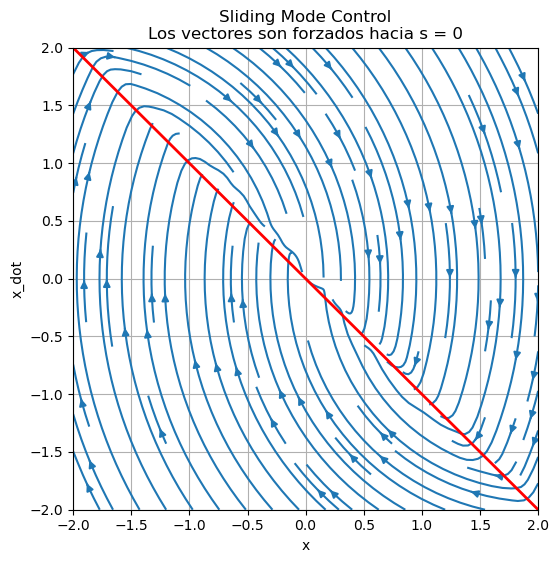

In [4]:
# Accion de control
U = -K * np.sign(s)

# Nueva dinámica
X1_dot_smc = X2
X2_dot_smc = -(k/m) * X1 - (b/m)*X2 + U/m

# Campo vectorial con SMC
plt.figure(figsize=(6,6))

plt.streamplot(X1, X2, X1_dot_smc, X2_dot_smc, density=1.2)
plt.contour(X1, X2, s, levels=[0], colors='r', linewidths=2)

plt.xlabel("x")
plt.ylabel("x_dot")
plt.title("Sliding Mode Control\nLos vectores son forzados hacia s = 0")
plt.grid()
plt.show()


## Reaching vs Sliding

En el plano de estados se distinguen dos fases:

- **Reaching phase**  
  La trayectoria se mueve hacia la superficie desde condiciones iniciales arbitrarias.

- **Sliding phase**  
  Una vez alcanzada, el sistema evoluciona sobre la superficie
  siguiendo la dinámica impuesta por \( s(x) = 0 \).

Visualmente:
- el control “dobla” los vectores de la dinámica natural
- hasta alinearlos con la superficie deslizante.

---

## Interpretación geométrica

- La superficie \( s(x)=0 \) es una **subvariedad diferenciable** del espacio de estados.
- El control actúa en dos niveles:
  - transversalmente: para alcanzar la variedad
  - tangencialmente: para mantener la evolución sobre ella
- La robustez surge porque la condición \( s \dot s < 0 \) no requiere
  un modelo exacto del sistema.

---

## Nota sobre chattering

El uso de \( \text{sign}(s) \) genera conmutaciones rápidas cerca de la superficie.

En la práctica se utiliza una aproximación suave:

\[
\text{sign}(s) \;\rightarrow\; \tanh\left(\frac{s}{\varepsilon}\right)
\]

lo que define una **capa límite** alrededor de la superficie.

---

## Idea clave

> En Sliding Mode Control no se controla directamente el estado,
> sino la **geometría de la dinámica**.



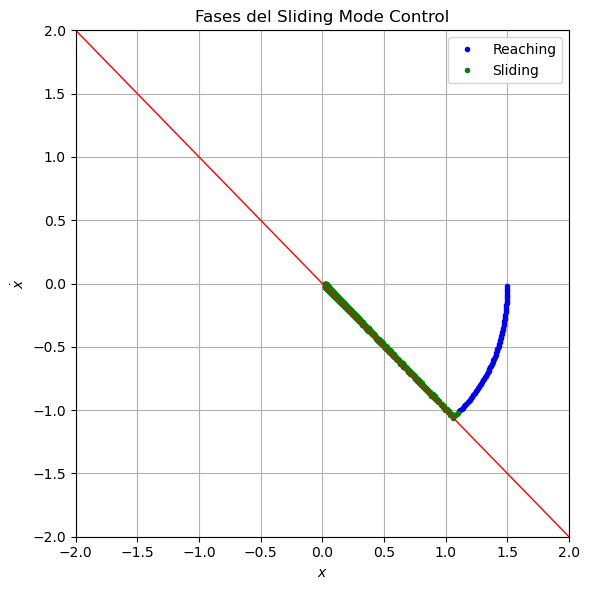

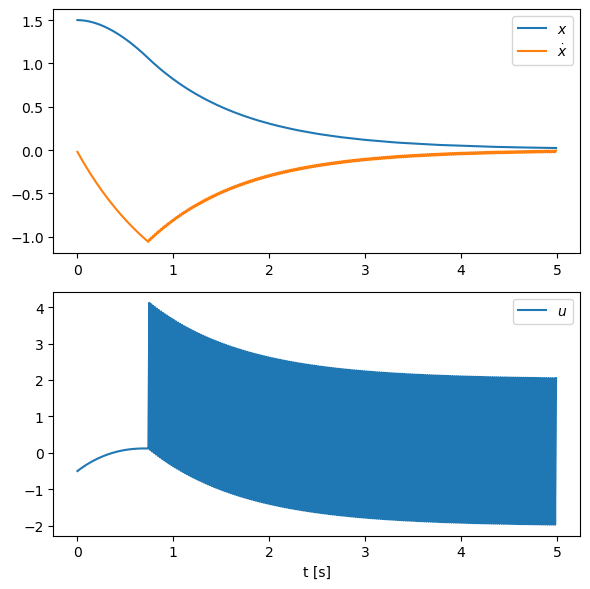

In [5]:
# Trayectoria individual sin pérdidas (b=0)
dt = 0.01
T = 5
t = np.arange(0, T, dt)
N = len(t)

x = np.array([1.5, 0.0])

s = np.zeros(N)
u = np.zeros(N)
traj = np.zeros((N, 2))
for i in range(N):
    s[i] = x[1] + lambda_s * x[0]
    # Acción de control para desplazamiento transversal a la variedad (alcanzabilidad => s=0)
    u_sw = -K * np.sign(s[i])
    # Si quiero eliminar el chattering, descomentar
    #u_sw = -K * np.tanh(s[i]/0.1)
    # Acción de control que garantiza la invariancia (=> s_punto=0)
    u_eq = k * x[0] - lambda_s *x[1]
    u[i] = u_sw + u_eq

    xdot = np.array([
        x[1],
        -(k/m)*x[0] + u[i]/m
    ])

    # Integro sin demasiadas vueltas con Euler
    x += xdot * dt
    traj[i] = x

s_field = X2 + lambda_s * X1

eps = 0.1
sliding_mask  = np.abs(s) <= eps
reaching_mask = np.abs(s) >  eps

plt.figure(figsize=(6,6))
# Trayectoria en reaching (azul)
plt.plot(traj[reaching_mask, 0],
         traj[reaching_mask, 1],
         'b.', label="Reaching")
# Trayectoria en sliding (verde)
plt.plot(traj[sliding_mask, 0],
         traj[sliding_mask, 1],
         'g.', label="Sliding")
# Superficie deslizante
plt.contour(X1, X2, s_field, levels=[0], colors='r', linewidths=1)

plt.xlabel("$x$")
plt.ylabel("$\\dot{x}$")
plt.title("Fases del Sliding Mode Control")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,6))
plt.subplot(211)
plt.plot(t,traj[:,0],label='$x$')
plt.plot(t,traj[:,1],label='$\\dot{x}$')
plt.legend(loc='upper right')
plt.subplot(212)
plt.plot(t,u,label='$u$')
plt.legend(loc='upper right')
plt.xlabel('t [s]')
plt.tight_layout()
plt.show()
